# EVOLUTION D'INDICATEURS COVID AVEC MATPLOTLIB

In [19]:
# Initialisation
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd

In [20]:
# On collecte les données d'hospitalisation et on les agrèg par jour
hospFR = pd.read_csv("https://www.data.gouv.fr/fr/datasets/r/63352e38-d353-4b54-bfd1-f1b3ee1cabd7",sep=';',error_bad_lines=False)

# les donnée sont pour hospitalisation et réa l'état par jour, ce n'est pas un cumul, pour les retours et les dc oui
hospFR.jour=pd.to_datetime(hospFR.jour,infer_datetime_format=True)
hospFRagg=hospFR.groupby(['jour'])['hosp','rea','rad','dc'].sum()
hospFRagg.columns=['hospitalisations','reanimations','retours','deces']

# les hospitalisations sont l'état chaque jour, si on ajoute retours et déces on a le cumul dhosp depuis le debut
hospFRagg['hospitalisationsBRUT']=hospFRagg['hospitalisations']+hospFRagg['retours']+hospFRagg['deces']

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:6: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  


In [21]:
# Examinons les données
# l'index est le jour
hospFRagg.head()

,hospitalisations,reanimations,retours,deces,hospitalisationsBRUT
jour,,,,,
2020-03-18,5905,1535,1627,435,7967
2020-03-19,7961,1975,2322,642,10925
2020-03-20,10272,2564,3128,890,14290
2020-03-21,11599,2872,3580,1041,16220
2020-03-22,13675,3311,4188,1251,19114


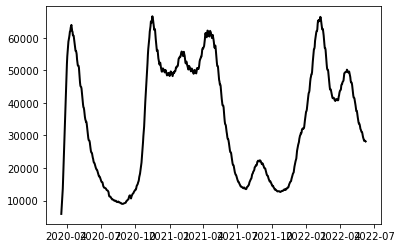

In [22]:
plt.plot(hospFRagg['hospitalisations'], color='black',lw=2, label = 'état des hospitalisations en t')

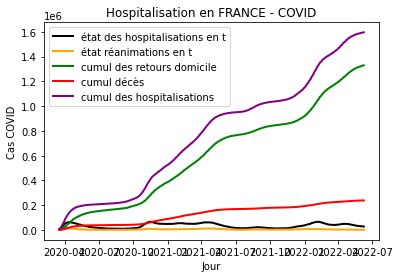

In [23]:
plt.plot(hospFRagg['hospitalisations'], color='black',lw=2, label = 'état des hospitalisations en t')
plt.plot(hospFRagg['reanimations'], color='orange',lw=2, label = 'état réanimations en t')
plt.plot(hospFRagg['retours'], color='green',lw=2, label = 'cumul des retours domicile')
plt.plot(hospFRagg['deces'], color='red',lw=2, label = 'cumul décès')
plt.plot(hospFRagg['hospitalisationsBRUT'], color='purple',lw=2, label = 'cumul des hospitalisations')
plt.xlabel('Jour'); plt.ylabel('Cas COVID'); plt.title('Hospitalisation en FRANCE - COVID')
plt.legend()
plt.savefig('graph.jpg')